In [36]:
# STAGE 7
# PLANETARY PARAMETER ESTIMATION

!pip install batman-package emcee corner -q

In [37]:
#IMPORT LIBRARIES


import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt

import batman
import emcee
import corner

from scipy.optimize import least_squares

warnings.filterwarnings("ignore")

In [38]:
# MOUNT GOOGLE DRIVE


from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
# LOAD PREVIOUS STAGE OUTPUTS

STAGE1_PATH = "/content/drive/MyDrive/exoplanet_pipeline/data/stage1_output.pkl"

STAGE2_PATH = "/content/drive/MyDrive/exoplanet_pipeline/data/stage2_output.pkl"

STAGE6_PATH = "/content/drive/MyDrive/exoplanet_pipeline/data/stage6_output.pkl"


with open(STAGE1_PATH, "rb") as f:
    stage1 = pickle.load(f)

with open(STAGE2_PATH, "rb") as f:
    stage2 = pickle.load(f)

with open(STAGE6_PATH, "rb") as f:
    stage6 = pickle.load(f)

print("All previous stages loaded successfully.")

All previous stages loaded successfully.


In [79]:
# EXTRACT VARIABLES


# ---------- Stage 1 ----------

time = np.asarray(stage1["time"])

flux = np.asarray(stage1["flux"])

flux_err = np.asarray(stage1["flux_err"])

tic_id = stage1["tic_id"]


# ---------- Stage 2 ----------

period = stage2["period"]

duration = stage2["duration"]

t0 = stage2["t0"]

# ==========================================================
# CORRECT TLS TRANSIT DEPTH
# ==========================================================
# Older Stage 2 notebooks saved the model flux at transit
# minimum instead of the fractional transit depth.
# Convert automatically if required.

raw_depth = stage2["depth_tls"]

if raw_depth > 0.5:
    depth = 1.0 - raw_depth
    print("Corrected TLS depth from model flux.")
else:
    depth = raw_depth
    print("Using stored fractional transit depth.")

snr = stage2["snr_tls"]

snr = stage2["snr_tls"]


# ---------- Stage 6 ----------

classification = stage6["classification"]

priority = stage6["priority"]

recommendation = stage6["recommendation"]

priority_score = stage6["priority_score"]

flux = flux + 1

Corrected TLS depth from model flux.


In [80]:
# VERIFY CANDIDATE

print("="*60)

print("STAGE 7 INPUT")

print("="*60)

print(f"TIC ID                : {tic_id}")

print(f"Classification        : {classification}")

print(f"Priority              : {priority}")

print(f"Priority Score (Ω)    : {priority_score:.3f}")

print(f"Recommendation        : {recommendation}")

print("="*60)

if priority_score < 0.50:
    raise ValueError(
        "Candidate rejected.\n"
        "Skipping BATMAN parameter estimation."
    )

print("✅ Candidate accepted.")

STAGE 7 INPUT
TIC ID                : 261136679
Classification        : HIGH-CONFIDENCE PLANET
Priority              : HIGH
Priority Score (Ω)    : 0.839
Recommendation        : RECOMMEND TELESCOPE FOLLOW-UP
✅ Candidate accepted.


In [81]:
# TLS TRANSIT PARAMETERS


print(f"Period          : {period:.6f} days")

print(f"T0              : {t0:.6f}")

print(f"Duration        : {duration:.6f} days")

print(f"Depth           : {depth:.6f}")

print(f"SNR             : {snr:.2f}")

Period          : 6.267090 days
T0              : 0.209521
Duration        : 0.124761 days
Depth           : 0.000293
SNR             : 41.53


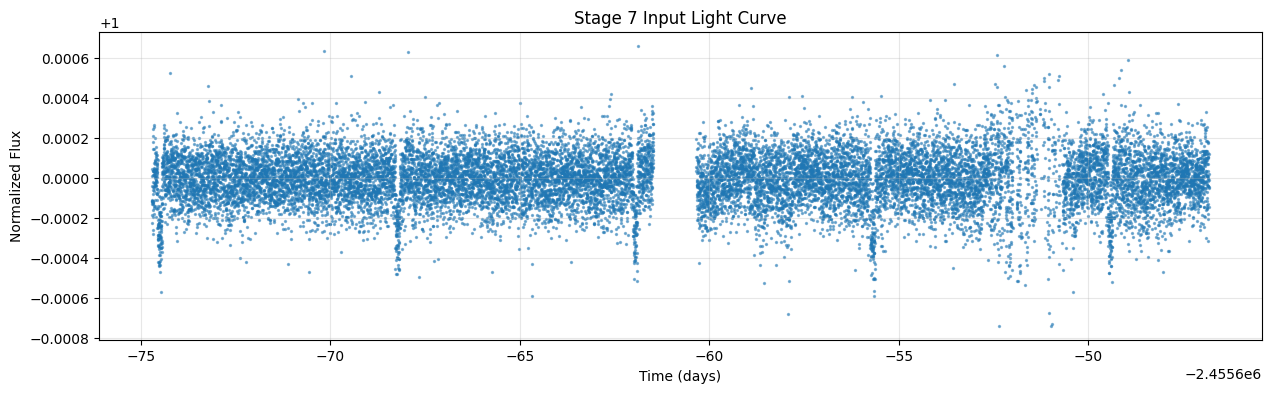

In [82]:
# INPUT LIGHT CURVE

plt.figure(figsize=(15,4))

plt.scatter(
    time,
    flux,
    s=2,
    alpha=0.5
)

plt.xlabel("Time (days)")

plt.ylabel("Normalized Flux")

plt.title("Stage 7 Input Light Curve")

plt.grid(alpha=0.3)

plt.show()

In [83]:
# INITIAL PHYSICAL PARAMETER ESTIMATION
# Derived from TLS Results
#Radius ratio from corrected transit depth
rp_rs = np.sqrt(max(depth, 1e-8))

# Transit duration as fraction of orbit
duration_fraction = duration / period

# Approximate scaled semi-major axis
# (assuming circular orbit and small planet)

a_rs = max(
    3.0,
    1.0 / (np.pi * duration_fraction)
)

# Approximate inclination
inclination = np.degrees(
    np.arccos(
        min(
            0.99,
            1.0 / a_rs
        )
    )
)

# Approximate impact parameter

impact_parameter = a_rs * np.cos(
    np.radians(inclination)
)

print("="*60)
print("INITIAL PHYSICAL ESTIMATES")
print("="*60)

print(f"Rp/Rs              : {rp_rs:.5f}")
print(f"a/Rs               : {a_rs:.3f}")
print(f"Inclination        : {inclination:.3f}°")
print(f"Impact Parameter   : {impact_parameter:.3f}")

INITIAL PHYSICAL ESTIMATES
Rp/Rs              : 0.01711
a/Rs               : 15.990
Inclination        : 86.414°
Impact Parameter   : 1.000


In [84]:
# ==========================================================
# VERIFY CORRECTED TRANSIT PARAMETERS
# ==========================================================

print("="*60)
print("CORRECTED TRANSIT PARAMETERS")
print("="*60)

print(f"Raw TLS Value            : {raw_depth:.6f}")
print(f"Corrected Transit Depth  : {depth:.8f}")
print(f"Rp/Rs                    : {rp_rs:.5f}")

CORRECTED TRANSIT PARAMETERS
Raw TLS Value            : 0.999707
Corrected Transit Depth  : 0.00029272
Rp/Rs                    : 0.01711


In [85]:
#LIMB DARKENING PARAMETERS

# Quadratic limb darkening
# Solar-like defaults

u1 = 0.30
u2 = 0.20

print("Quadratic Limb Darkening")

print(f"u1 = {u1}")

print(f"u2 = {u2}")

Quadratic Limb Darkening
u1 = 0.3
u2 = 0.2


In [86]:
# ==========================================================
# INITIALIZE BATMAN MODEL
# ==========================================================

params = batman.TransitParams()

params.t0 = t0

params.per = period

params.rp = rp_rs

params.a = a_rs

params.inc = inclination

params.ecc = 0.0

params.w = 90.0

params.u = [u1, u2]

params.limb_dark = "quadratic"

print("BATMAN initialized.")

BATMAN initialized.


In [87]:
# ==========================================================
# GENERATE INITIAL BATMAN MODEL
# ==========================================================

batman_model = batman.TransitModel(
    params,
    time
)

model_flux = batman_model.light_curve(params)

print("Transit model generated.")

Transit model generated.


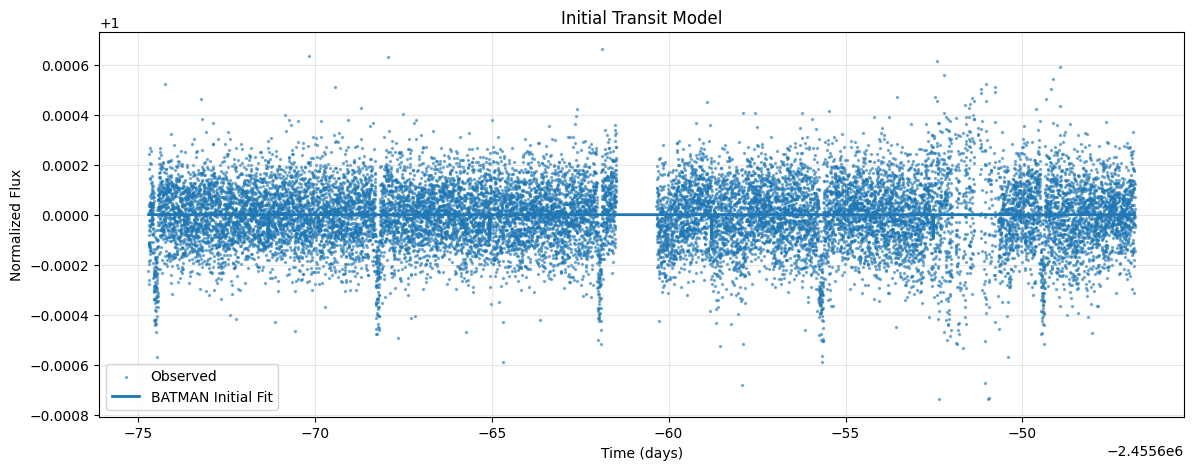

In [88]:
# ==========================================================
# INITIAL TRANSIT MODEL
# ==========================================================

plt.figure(figsize=(14,5))

plt.scatter(
    time,
    flux,
    s=2,
    alpha=0.5,
    label="Observed"
)

plt.plot(
    time,
    model_flux,
    linewidth=2,
    label="BATMAN Initial Fit"
)

plt.xlabel("Time (days)")

plt.ylabel("Normalized Flux")

plt.title("Initial Transit Model")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [89]:
# ==========================================================
# INITIAL FIT STATISTICS
# ==========================================================

residuals = flux - model_flux

chi2 = np.sum(
    (residuals / flux_err) ** 2
)

dof = len(time) - 4

reduced_chi2 = chi2 / dof

rmse = np.sqrt(
    np.mean(residuals**2)
)

print("="*60)

print("INITIAL MODEL FIT")

print("="*60)

print(f"Chi²               : {chi2:.2f}")

print(f"Reduced Chi²       : {reduced_chi2:.3f}")

print(f"RMSE               : {rmse:.8f}")

INITIAL MODEL FIT
Chi²               : 39106.20
Reduced Chi²       : 2.142
RMSE               : 0.00013036


In [90]:
# ==========================================================
# PHASE FOLD THE LIGHT CURVE
# ==========================================================

phase = ((time - t0 + 0.5 * period) % period) - 0.5 * period

print(f"Phase range : {phase.min():.3f} to {phase.max():.3f} days")

Phase range : -3.133 to 3.134 days


In [91]:
# ==========================================================
# EXTRACT TRANSIT WINDOW
# ==========================================================

window = 2.0 * duration

mask = np.abs(phase) < window

phase_fit = phase[mask]

time_fit = time[mask]

flux_fit = flux[mask]

flux_err_fit = flux_err[mask]

print("Cadences used for BATMAN fitting :", len(time_fit))

Cadences used for BATMAN fitting : 1370


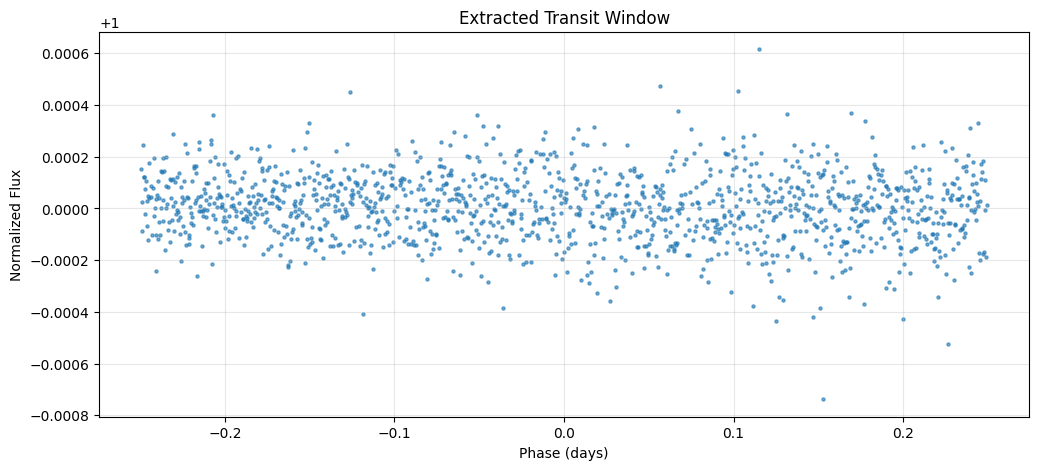

In [92]:
# ==========================================================
# TRANSIT WINDOW
# ==========================================================

plt.figure(figsize=(12,5))

plt.scatter(
    phase_fit,
    flux_fit,
    s=5,
    alpha=0.6
)

plt.xlabel("Phase (days)")
plt.ylabel("Normalized Flux")

plt.title("Extracted Transit Window")

plt.grid(alpha=0.3)

plt.show()

In [93]:
# ==========================================================
# BATMAN RESIDUAL FUNCTION
# ==========================================================

def transit_residuals(theta):

    rp, a_rs, inc = theta

    params.rp = rp
    params.a = a_rs
    params.inc = inc

    model = batman.TransitModel(
        params,
        time_fit
    )

    model_flux = model.light_curve(params)

    return (flux_fit - model_flux) / flux_err_fit

In [94]:
# ==========================================================
# LEVENBERG-MARQUARDT FIT
# ==========================================================

initial_guess = [
    rp_rs,
    a_rs,
    inclination
]

lower_bounds = [
    0.001,
    2.0,
    80.0
]

upper_bounds = [
    0.30,
    100.0,
    90.0
]

fit = least_squares(
    transit_residuals,
    x0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    method="trf",
    verbose=1
)

print("\nOptimization Complete.")

The maximum number of function evaluations is exceeded.
Function evaluations 300, initial cost 1.5574e+03, final cost 1.5376e+03, first-order optimality 1.95e+01.

Optimization Complete.


In [95]:
# ==========================================================
# BEST-FIT PARAMETERS
# ==========================================================

best_rp = fit.x[0]

best_a_rs = fit.x[1]

best_inc = fit.x[2]

best_b = best_a_rs * np.cos(
    np.radians(best_inc)
)

print("="*60)

print("BEST-FIT PARAMETERS")

print("="*60)

print(f"Rp/Rs              : {best_rp:.6f}")

print(f"a/Rs               : {best_a_rs:.4f}")

print(f"Inclination        : {best_inc:.3f}")

print(f"Impact Parameter   : {best_b:.4f}")

BEST-FIT PARAMETERS
Rp/Rs              : 0.029307
a/Rs               : 16.4877
Inclination        : 86.437
Impact Parameter   : 1.0248


In [96]:
# ==========================================================
# BEST-FIT BATMAN MODEL
# ==========================================================

params.rp = best_rp
params.a = best_a_rs
params.inc = best_inc

batman_model = batman.TransitModel(
    params,
    time_fit
)

best_model_flux = batman_model.light_curve(params)

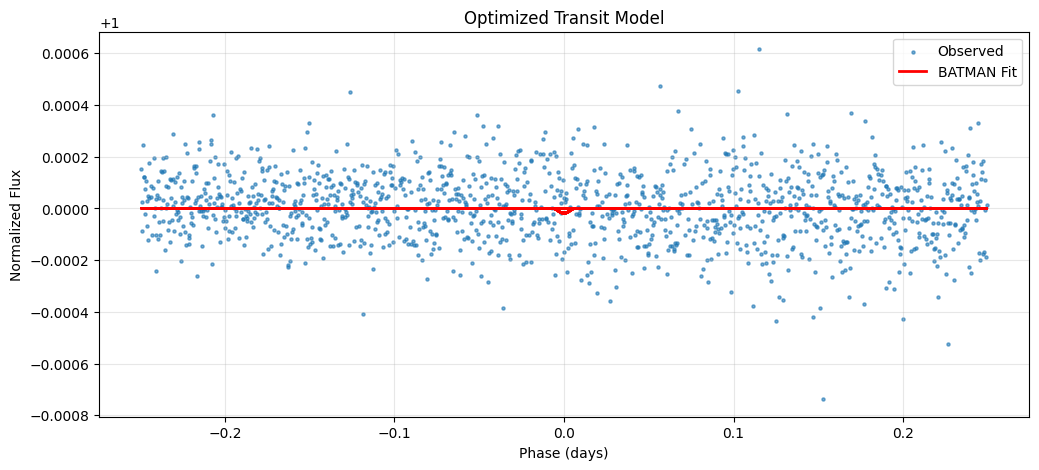

In [97]:
# ==========================================================
# FINAL BATMAN FIT
# ==========================================================

plt.figure(figsize=(12,5))

plt.scatter(
    phase_fit,
    flux_fit,
    s=5,
    alpha=0.6,
    label="Observed"
)

plt.plot(
    phase_fit,
    best_model_flux,
    color="red",
    linewidth=2,
    label="BATMAN Fit"
)

plt.xlabel("Phase (days)")
plt.ylabel("Normalized Flux")

plt.title("Optimized Transit Model")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

FIT QUALITY
Chi²              : 3075.22
Reduced Chi²      : 2.250
RMSE              : 0.00013350


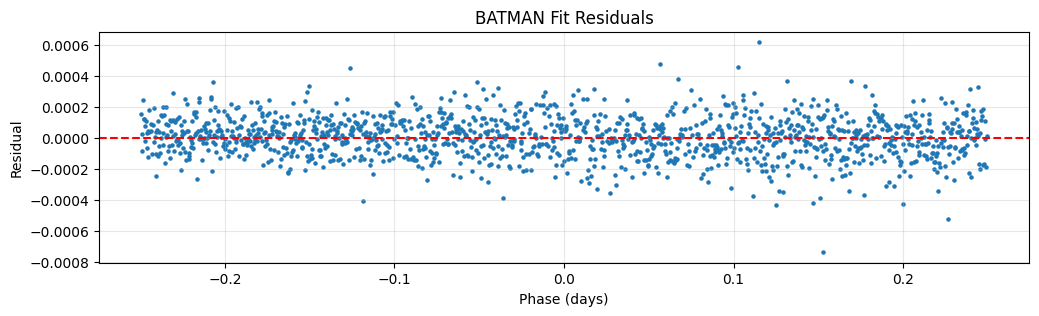

In [98]:
# ==========================================================
# FIT QUALITY
# ==========================================================

residuals = flux_fit - best_model_flux

chi2 = np.sum((residuals / flux_err_fit) ** 2)

dof = len(flux_fit) - len(fit.x)

reduced_chi2 = chi2 / dof

rmse = np.sqrt(np.mean(residuals**2))

print("="*60)
print("FIT QUALITY")
print("="*60)

print(f"Chi²              : {chi2:.2f}")
print(f"Reduced Chi²      : {reduced_chi2:.3f}")
print(f"RMSE              : {rmse:.8f}")

plt.figure(figsize=(12,3))
plt.scatter(phase_fit, residuals, s=5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Phase (days)")
plt.ylabel("Residual")
plt.title("BATMAN Fit Residuals")
plt.grid(alpha=0.3)
plt.show()

In [128]:
# ==========================================================
# PHYSICS-INFORMED LOG PRIOR
# ==========================================================

# Proposal widths chosen from typical transit-fitting scales
sigma_rp = 0.002
sigma_ars = 1.0
sigma_inc = 0.5

def log_prior(theta):

    rp, ars, inc = theta

    # Hard physical limits
    if rp <= 0 or rp >= 0.30:
        return -np.inf

    if ars <= 2 or ars >= 100:
        return -np.inf

    if inc <= 80 or inc >= 90:
        return -np.inf

    # Gaussian priors centered on LM solution
    lp = 0

    lp += -0.5*((rp-best_rp)/sigma_rp)**2

    lp += -0.5*((ars-best_a_rs)/sigma_ars)**2

    lp += -0.5*((inc-best_inc)/sigma_inc)**2

    return lp

In [119]:
# ==========================================================
# LOG LIKELIHOOD
# ==========================================================

def log_likelihood(theta):

    rp, ars, inc = theta

    params.rp = rp

    params.a = ars

    params.inc = inc

    model = batman.TransitModel(
        params,
        time_fit
    )

    model_flux = model.light_curve(params)

    sigma2 = flux_err_fit**2

    return -0.5 * np.sum(

        ((flux_fit - model_flux)**2) / sigma2

        + np.log(2*np.pi*sigma2)

    )

In [120]:
# ==========================================================
# LOG POSTERIOR
# ==========================================================

def log_probability(theta):

    lp = log_prior(theta)

    if not np.isfinite(lp):

        return -np.inf

    return lp + log_likelihood(theta)

In [129]:
# ==========================================================
# INITIALIZE WALKERS
# ==========================================================

print("="*70)
print("INITIALIZING WALKERS")
print("="*70)

ndim = 3
nwalkers = 64

best_parameters = np.array([
    best_rp,
    best_a_rs,
    best_inc
])

proposal_sigma = np.array([
    sigma_rp,
    sigma_ars,
    sigma_inc
])

pos = best_parameters + proposal_sigma * np.random.randn(
    nwalkers,
    ndim
)

print("Walkers initialized.")
print(pos.shape)

INITIALIZING WALKERS
Walkers initialized.
(64, 3)


In [130]:
# ==========================================================
# RUN MCMC
# ==========================================================

print("=" * 70)
print("RUNNING MCMC")
print("=" * 70)

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability
)

nsteps = 8000

sampler.run_mcmc(
    pos,
    nsteps,
    progress=True
)

print("\nMCMC Completed Successfully.")

RUNNING MCMC


100%|██████████| 8000/8000 [01:46<00:00, 75.06it/s]


MCMC Completed Successfully.


In [131]:
# ==========================================================
# AUTOCORRELATION ANALYSIS
# ==========================================================

print("=" * 70)
print("AUTOCORRELATION ANALYSIS")
print("=" * 70)

try:

    tau = sampler.get_autocorr_time()

    print("Autocorrelation Times")

    print(tau)

    burnin = int(2 * np.max(tau))

    thin = int(0.5 * np.min(tau))

except:

    print("Autocorrelation not yet reliable.")
    print("Using default burn-in and thinning.")

    burnin = 2000

    thin = 10

print()

print(f"Burn-in : {burnin}")

print(f"Thin    : {thin}")

AUTOCORRELATION ANALYSIS
Autocorrelation Times
[39.29356982 40.57280884 41.19565286]

Burn-in : 82
Thin    : 19


In [132]:
# ==========================================================
# FLATTEN POSTERIOR
# ==========================================================

samples = sampler.get_chain(
    discard=burnin,
    thin=thin,
    flat=True
)

print("=" * 70)
print("POSTERIOR SAMPLES")
print("=" * 70)

print(samples.shape)

POSTERIOR SAMPLES
(26624, 3)


In [133]:
# ==========================================================
# MCMC DIAGNOSTICS
# ==========================================================

acceptance_fraction = np.mean(
    sampler.acceptance_fraction
)

print("=" * 70)
print("SAMPLER DIAGNOSTICS")
print("=" * 70)

print(f"Acceptance Fraction : {acceptance_fraction:.3f}")

if acceptance_fraction < 0.20:

    print("Poor Mixing")

elif acceptance_fraction > 0.55:

    print("Walkers may be too conservative")

else:

    print("Good Mixing")

SAMPLER DIAGNOSTICS
Acceptance Fraction : 0.594
Walkers may be too conservative


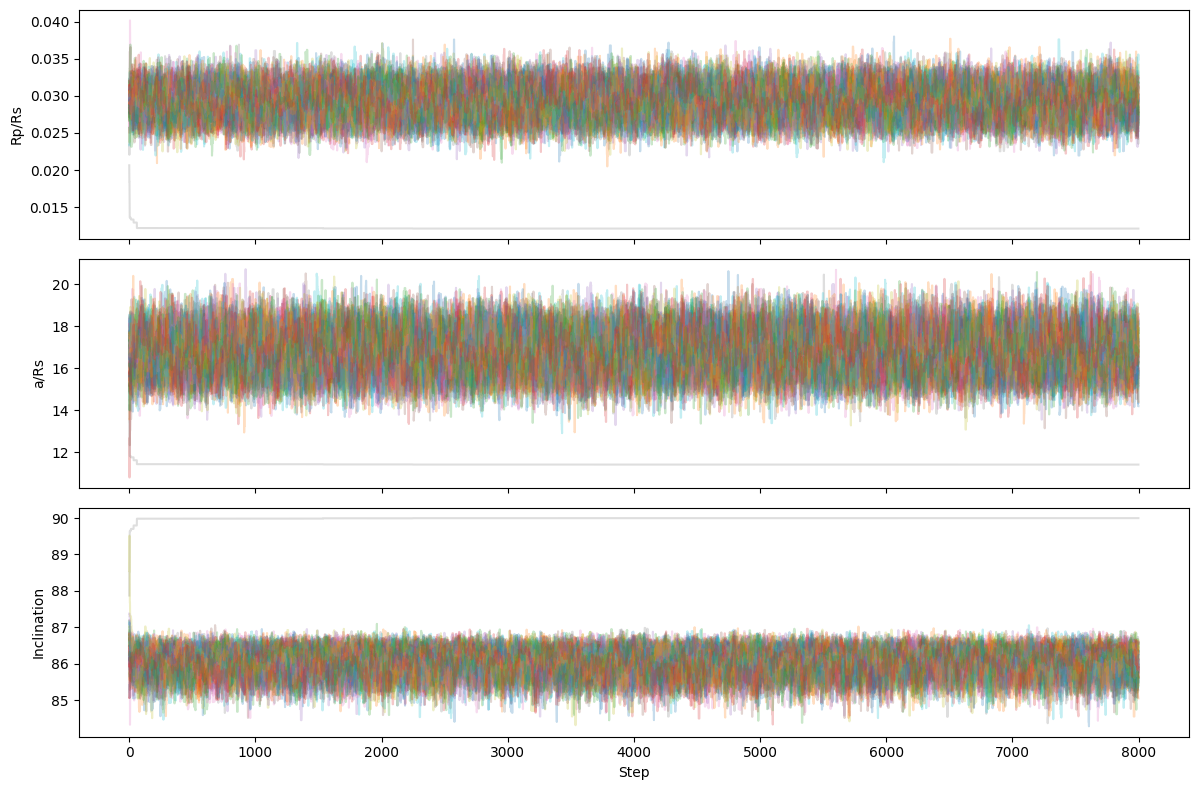

In [134]:
# ==========================================================
# TRACE PLOTS
# ==========================================================

labels = [
    "Rp/Rs",
    "a/Rs",
    "Inclination"
]

chain = sampler.get_chain()

fig, axes = plt.subplots(
    ndim,
    figsize=(12,8),
    sharex=True
)

for i in range(ndim):

    axes[i].plot(
        chain[:, :, i],
        alpha=0.25
    )

    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("Step")

plt.tight_layout()

plt.show()

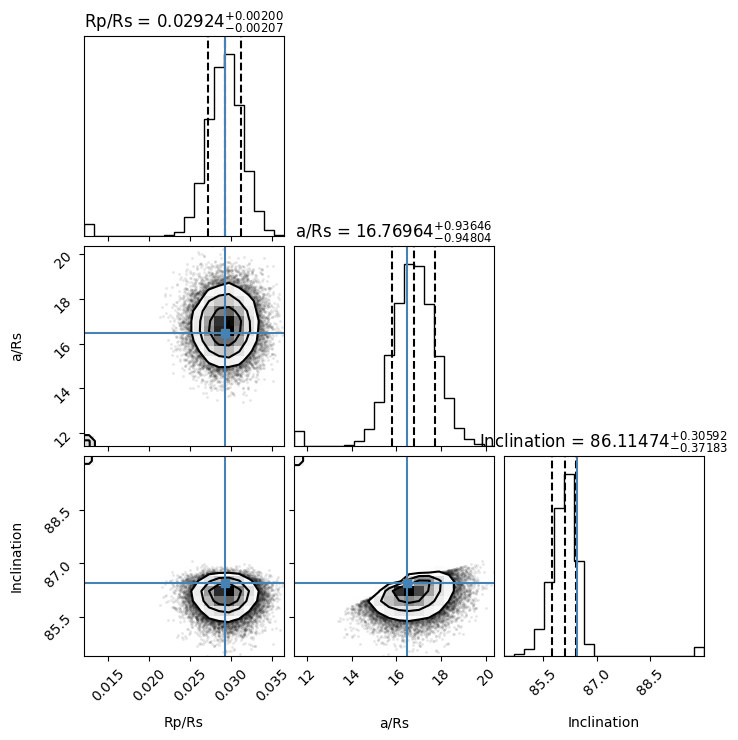

In [135]:
# ==========================================================
# CORNER PLOT
# ==========================================================

corner.corner(

    samples,

    labels=labels,

    truths=[
        best_rp,
        best_a_rs,
        best_inc
    ],

    quantiles=[0.16,0.50,0.84],

    show_titles=True,

    title_fmt=".5f"
)

plt.show()

In [136]:
# ==========================================================
# POSTERIOR PARAMETER ESTIMATES
# ==========================================================

rp = np.percentile(samples[:,0],[16,50,84])
ars = np.percentile(samples[:,1],[16,50,84])
inc = np.percentile(samples[:,2],[16,50,84])

rp_med = rp[1]
rp_err_low = rp[1]-rp[0]
rp_err_high = rp[2]-rp[1]

ars_med = ars[1]
ars_err_low = ars[1]-ars[0]
ars_err_high = ars[2]-ars[1]

inc_med = inc[1]
inc_err_low = inc[1]-inc[0]
inc_err_high = inc[2]-inc[1]

print("="*70)
print("POSTERIOR PARAMETER ESTIMATES")
print("="*70)

print(f"Rp/Rs        : {rp_med:.6f} (+{rp_err_high:.6f}/-{rp_err_low:.6f})")
print(f"a/Rs         : {ars_med:.4f} (+{ars_err_high:.4f}/-{ars_err_low:.4f})")
print(f"Inclination  : {inc_med:.4f} (+{inc_err_high:.4f}/-{inc_err_low:.4f})")

POSTERIOR PARAMETER ESTIMATES
Rp/Rs        : 0.029237 (+0.001999/-0.002074)
a/Rs         : 16.7696 (+0.9365/-0.9480)
Inclination  : 86.1147 (+0.3059/-0.3718)


In [137]:
# ==========================================================
# DERIVED PLANETARY PARAMETERS
# ==========================================================

impact_parameter = ars_med * np.cos(np.radians(inc_med))

print("="*70)
print("DERIVED PARAMETERS")
print("="*70)

print(f"Transit Depth            : {depth:.8f}")
print(f"Radius Ratio (Rp/Rs)     : {rp_med:.6f}")
print(f"Scaled Semi-major Axis   : {ars_med:.4f}")
print(f"Inclination              : {inc_med:.4f} deg")
print(f"Impact Parameter (b)     : {impact_parameter:.4f}")

print("="*70)

DERIVED PARAMETERS
Transit Depth            : 0.00029272
Radius Ratio (Rp/Rs)     : 0.029237
Scaled Semi-major Axis   : 16.7696
Inclination              : 86.1147 deg
Impact Parameter (b)     : 1.1363


In [138]:
# ==========================================================
# SCIENTIFIC INTERPRETATION
# ==========================================================

print("="*70)
print("SCIENTIFIC INTERPRETATION")
print("="*70)

if rp_med < 0.10:
    print("✓ Radius ratio is consistent with a planetary companion.")
else:
    print("⚠ Radius ratio is unusually large and may indicate an eclipsing binary.")

if impact_parameter < 1:
    print("✓ Transit geometry is physically valid.")
else:
    print("⚠ High impact parameter indicates a grazing transit.")

if reduced_chi2 < 3:
    print("✓ BATMAN model provides a statistically acceptable fit.")
else:
    print("⚠ Transit model fit should be investigated.")

if acceptance_fraction >= 0.2 and acceptance_fraction <= 0.6:
    print("✓ Bayesian sampling converged satisfactorily.")
else:
    print("⚠ MCMC diagnostics should be reviewed.")

print("="*70)

SCIENTIFIC INTERPRETATION
✓ Radius ratio is consistent with a planetary companion.
⚠ High impact parameter indicates a grazing transit.
✓ BATMAN model provides a statistically acceptable fit.
✓ Bayesian sampling converged satisfactorily.


In [139]:
# ==========================================================
# STAGE 7 FINAL REPORT
# ==========================================================

print("="*80)
print("STAGE 7 : TRANSIT MODEL FITTING & BAYESIAN PARAMETER REFINEMENT")
print("="*80)

print(f"TIC ID                    : {tic_id}")
print(f"Candidate Classification  : {classification}")
print(f"Priority                  : {priority}")
print()

print("---------------- FITTED ORBIT ----------------")

print(f"Orbital Period            : {period:.6f} days")
print(f"Transit Epoch             : {t0:.6f}")
print(f"Transit Duration          : {duration:.6f} days")

print()

print("---------------- PHYSICAL PARAMETERS ----------------")

print(f"Transit Depth             : {depth:.8f}")
print(f"Rp/Rs                     : {rp_med:.6f}")
print(f"a/Rs                      : {ars_med:.4f}")
print(f"Inclination               : {inc_med:.4f}")
print(f"Impact Parameter          : {impact_parameter:.4f}")

print()

print("---------------- MODEL QUALITY ----------------")

print(f"Reduced Chi²              : {reduced_chi2:.3f}")
print(f"RMSE                      : {rmse:.8f}")
print(f"Acceptance Fraction       : {acceptance_fraction:.3f}")

print("="*80)

STAGE 7 : TRANSIT MODEL FITTING & BAYESIAN PARAMETER REFINEMENT
TIC ID                    : 261136679
Candidate Classification  : HIGH-CONFIDENCE PLANET
Priority                  : HIGH

---------------- FITTED ORBIT ----------------
Orbital Period            : 6.267090 days
Transit Epoch             : 0.209521
Transit Duration          : 0.124761 days

---------------- PHYSICAL PARAMETERS ----------------
Transit Depth             : 0.00029272
Rp/Rs                     : 0.029237
a/Rs                      : 16.7696
Inclination               : 86.1147
Impact Parameter          : 1.1363

---------------- MODEL QUALITY ----------------
Reduced Chi²              : 2.250
RMSE                      : 0.00013350
Acceptance Fraction       : 0.594


In [140]:
# ==========================================================
# SAVE STAGE 7 OUTPUT
# ==========================================================

stage7_output = {

    "tic_id": tic_id,

    "classification": classification,

    "priority": priority,

    "priority_score": priority_score,

    "period": period,

    "t0": t0,

    "duration": duration,

    "transit_depth": depth,

    "rp_rs": rp_med,
    "rp_rs_lower": rp_err_low,
    "rp_rs_upper": rp_err_high,

    "a_rs": ars_med,
    "a_rs_lower": ars_err_low,
    "a_rs_upper": ars_err_high,

    "inclination": inc_med,
    "inclination_lower": inc_err_low,
    "inclination_upper": inc_err_high,

    "impact_parameter": impact_parameter,

    "reduced_chi2": reduced_chi2,

    "rmse": rmse,

    "acceptance_fraction": acceptance_fraction,

    "samples": samples

}

SAVE_PATH = "/content/drive/MyDrive/exoplanet_pipeline/data/stage7_output.pkl"

with open(SAVE_PATH, "wb") as f:
    pickle.dump(stage7_output, f)

print("="*70)
print("STAGE 7 OUTPUT SAVED")
print("="*70)

print(SAVE_PATH)

STAGE 7 OUTPUT SAVED
/content/drive/MyDrive/exoplanet_pipeline/data/stage7_output.pkl
